<a href="https://colab.research.google.com/github/NinoUAM/ECM_2526_FinalProject_Gr12/blob/main/Code_Interm%C3%A9diaire_Eq12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import requests
import time
import re
from typing import List, Dict
from bs4 import BeautifulSoup

## EDA

In [258]:
# Chargement du dataset
df = pd.read_csv("investments_VC.csv", encoding='latin1')

In [259]:
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [260]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [261]:
# Nettoyage des noms de colonnes
df = df.rename(columns={' market ': "market", ' funding_total_usd ': "funding_total_usd"})

In [262]:
# Définition des mots-clés pour isoler le secteur Santé/Pharma
pharma_keywords = ['pharma', 'biotech', 'abiotechnology', 'biopharmaceutical',
                  'drug', 'therapeutics', 'medicine', 'clinical']

mask = pd.Series([False] * len(df))

# Recherche dans les catégories et les marchés
if 'category_list' in df.columns:
    for keyword in pharma_keywords:
        mask |= df['category_list'].astype(str).str.lower().str.contains(keyword, na=False)

if 'market' in df.columns:
    for keyword in pharma_keywords:
        mask |= df['market'].astype(str).str.lower().str.contains(keyword, na=False)

# Création du sous-ensemble dédié au secteur Pharma
pharma_df = df[mask].copy()
pharma_df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
34,/organization/10x-technologies,10X Technologies,http://10xtechnologies.com,|Biotechnology|,Biotechnology,"30,00,000",operating,USA,CA,SF Bay Area,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
44,/organization/121nexus,121nexus,http://www.121nexus.com,|Politics|Technology|Medical Devices|Pharmaceu...,Pharmaceuticals,"7,94,000",operating,USA,RI,Providence,...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
97,/organization/20-20-gene-systems-inc,20/20 Gene Systems Inc.,http://2020gene.com,|Biotechnology|,Biotechnology,"1,50,000",operating,USA,MD,"Washington, D.C.",...,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
108,/organization/22nd-century-group,22nd Century Group,http://www.xxiicentury.com,|Biotechnology|,Biotechnology,"1,50,34,750",operating,USA,NY,NY - Other,...,0.0%,0.0%,242850000.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
112,/organization/23andme,23andMe,http://23andme.com,|Search|Biotechnology|,Biotechnology,"11,19,49,900",operating,USA,CA,SF Bay Area,...,0.0%,0.0%,900000000.0%,1260000000.0%,3100000000.0%,5794990000.0%,0.0%,0.0%,0.0%,0.0%


In [263]:
# Nombre d'entreprises uniques par statut (Opérationnelle, Acquise, Fermée)
pharma_df.groupby('status')['name'].nunique()

,name
status,
acquired,222
closed,142
operating,3666


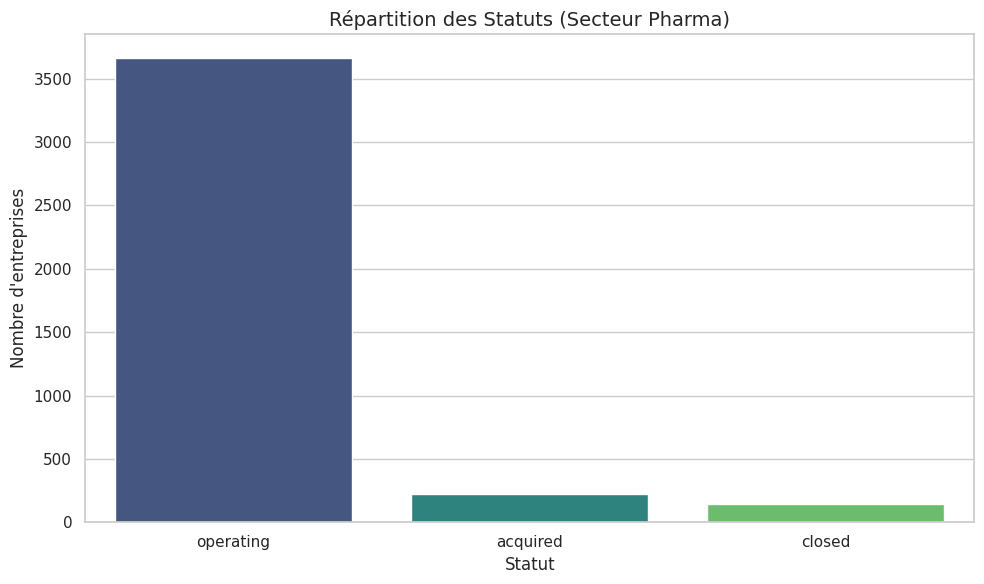

In [264]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Visualisation de la répartition par statut
sns.countplot(data=pharma_df, x='status', palette='viridis', ax=ax, hue='status', legend=False)
ax.set_title('Répartition des Statuts (Secteur Pharma)', fontsize=14)
ax.set_xlabel('Statut')
ax.set_ylabel('Nombre d\'entreprises')

plt.tight_layout()
plt.show()


In [265]:
pharma_df['funding_total_usd'] = (pharma_df['funding_total_usd']
                                  .astype(str)
                                  .str.strip()
                                  .str.replace(',', '', regex=False)
                                  .replace('-', np.nan)
                                  .replace('', np.nan))


pharma_df['funding_total_usd'] = pd.to_numeric(pharma_df['funding_total_usd'], errors='coerce')

## Features engineering

In [266]:
CUTOFF = '2012-01-01'
FUNDING_TYPES = ['seed', 'venture', 'grant', 'round_A', 'round_B']
COLS_NUMERIC = ['age', 'funding_total_usd', 'funding_rounds', 'days_to_first_funding',
                'funding_duration', 'funding_velocity', 'round_intensity']
FEATURES = COLS_NUMERIC + [f'has_{c}' for c in FUNDING_TYPES] + ['country_code']

In [267]:

def build_features(df, reference_date, fit_country_encoder=False, rare_countries=None):
    d = df.copy()
    ref = pd.to_datetime(reference_date)

    # Funding_total_usd
    d['funding_total_usd'] = pd.to_numeric(d['funding_total_usd'], errors='coerce')
    d['funding_total_usd'] = d['funding_total_usd'].fillna(d['funding_total_usd'].median())

    # Dates
    for col in ['founded_at', 'first_funding_at', 'last_funding_at']:
        d[col] = pd.to_datetime(d[col], errors='coerce')

    # Âge
    d['age'] = ((ref - d['founded_at']).dt.days / 365.25).clip(lower=0.1)

    # Durées de financement
    d['days_to_first_funding'] = (d['first_funding_at'] - d['founded_at']).dt.days
    last_funding_clipped = d['last_funding_at'].clip(upper=ref)
    d['funding_duration'] = (last_funding_clipped - d['first_funding_at']).dt.days

    # Ratios
    d['funding_velocity'] = d['funding_total_usd'] / d['age']
    d['round_intensity']  = d['funding_rounds'] / d['age']

    for col in FUNDING_TYPES:
        d[f'has_{col}'] = (d[col].fillna(0) > 0).astype(int)

    for col in COLS_NUMERIC:
        d[col] = d.groupby('market')[col].transform(lambda x: x.fillna(x.median()))
        d[col] = d[col].fillna(d[col].median())

    if fit_country_encoder:
        country_counts = d['country_code'].value_counts()
        rare_countries  = country_counts[country_counts < 10].index
    d['country_code'] = d['country_code'].replace(rare_countries, 'OTHER').fillna('UNKNOWN')

    if fit_country_encoder:
        return d, rare_countries
    return d


In [268]:

train_raw = pharma_df[
    (pd.to_datetime(pharma_df['founded_at']) < CUTOFF) &
    (pharma_df['status'] != 'operating')
].copy()

train_data, rare_countries = build_features(train_raw, CUTOFF, fit_country_encoder=True)

train_data['Profitable'] = (train_data['status'].isin(['acquired', 'ipo'])).astype(int)

print(f"Startups d'entraînement : {len(train_data)}")
print("\nÉquilibre des classes :")
print(train_data['Profitable'].value_counts())
print(f"Taux de succès : {train_data['Profitable'].mean():.1%}")
print(f"\nPays après regroupement : {train_data['country_code'].nunique()}")

X = pd.get_dummies(train_data[FEATURES], drop_first=True)
y = train_data['Profitable']

print(f"\nFeatures : {X.shape[1]}  |  NaN dans X : {X.isna().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_s = scaler_pipeline.fit_transform(X_train)
X_test_s  = scaler_pipeline.transform(X_test)

Startups d'entraînement : 272

Équilibre des classes :
Profitable
1    145
0    127
Name: count, dtype: int64
Taux de succès : 53.3%

Pays après regroupement : 4

Features : 15  |  NaN dans X : 0


#Modèle ML

##Entrainement

In [269]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, random_state=42),
    "SVM": SVC(class_weight='balanced', probability=True, random_state=42)
}


results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='f1')

    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    results.append({
        "Modele": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("RÉSULTATS DES MODÈLES")
print(df_results.to_string(index=False))

RÉSULTATS DES MODÈLES
             Modele  Accuracy  Precision  Recall  F1-Score
  Gradient Boosting     60.0%      61.3%   65.5%     63.3%
Logistic Regression     56.4%      57.6%   65.5%     61.3%
      Random Forest     56.4%      57.6%   65.5%     61.3%
                SVM     58.2%      60.7%   58.6%     59.6%


##Prédiction

In [270]:

scoring_raw = pharma_df[pharma_df['status'] == 'operating'].copy()
df_scoring  = build_features(scoring_raw, CUTOFF,
                              fit_country_encoder=False,
                              rare_countries=rare_countries)

X_scoring_raw     = pd.get_dummies(df_scoring[FEATURES], drop_first=True)
X_scoring_aligned = X_scoring_raw.reindex(columns=X.columns, fill_value=0).fillna(0)

X_scoring_scaled = scaler_pipeline.transform(X_scoring_aligned)

# Scores par modèle
for name, model in models.items():
    df_scoring[f'Score_{name}'] = model.predict_proba(X_scoring_scaled)[:, 1]

score_cols = [f'Score_{m}' for m in models]
df_scoring['Score_Consensus'] = df_scoring[score_cols].mean(axis=1)

# Affichage top 10
print("TOP 10 DES STARTUPS 'OPERATING' LES PLUS PROMETTEUSES")
cols_display = ['name', 'market', 'Score_Consensus'] + score_cols
top_10 = (df_scoring[cols_display]
          .sort_values('Score_Consensus', ascending=False)
          .head(10))

pd.options.display.float_format = '{:.1%}'.format
print(top_10.to_string(index=False))

output_path = "startups_scoring.csv"
df_scoring[cols_display].sort_values('Score_Consensus', ascending=False).to_csv(output_path, index=False, float_format='%.4f')

TOP 10 DES STARTUPS 'OPERATING' LES PLUS PROMETTEUSES
                    name            market  Score_Consensus  Score_Logistic Regression  Score_Random Forest  Score_Gradient Boosting  Score_SVM
  Sagent Pharmaceuticals      Health Care             86.4%                      78.8%                98.0%                    99.4%      69.2%
   Esperion Therapeutics      Health Care             86.0%                      90.2%                87.0%                    96.5%      70.2%
 VentiRx Pharmaceuticals  Pharmaceuticals             85.0%                      94.9%                93.0%                    87.1%      64.9%
                 Dermira    Biotechnology             84.9%                      80.8%                93.0%                    96.2%      69.5%
                Asuragen    Biotechnology             84.8%                      87.3%                94.0%                    96.7%      61.3%
  Eleven Biotherapeutics      Health Care             84.0%                      8

In [271]:
startups_scoring = pd.read_csv("startups_scoring.csv", encoding='latin1')

In [272]:
startups_scoring

,name,market,Score_Consensus,Score_Logistic Regression,Score_Random Forest,Score_Gradient Boosting,Score_SVM
0,Sagent Pharmaceuticals,Health Care,86.4%,78.8%,98.0%,99.4%,69.2%
1,Esperion Therapeutics,Health Care,86.0%,90.2%,87.0%,96.5%,70.2%
2,VentiRx Pharmaceuticals,Pharmaceuticals,85.0%,94.9%,93.0%,87.1%,64.9%
3,Dermira,Biotechnology,84.9%,80.8%,93.0%,96.2%,69.5%
4,Asuragen,Biotechnology,84.8%,87.3%,94.0%,96.7%,61.3%
...,...,...,...,...,...,...,...
3662,Siamab Therapeutics,Biotechnology,14.6%,10.7%,14.0%,1.9%,31.9%
3663,Clean TeQ,Biotechnology,14.6%,17.8%,7.0%,3.7%,29.8%
3664,Performance Genomics,Biotechnology,13.9%,0.7%,11.0%,5.9%,38.1%
3665,HyperStealth Biotechnology,Biotechnology,13.9%,1.3%,10.0%,5.9%,38.5%


#Modèle NLP

In [273]:
class MultiSourceEthicalExtractor:
    """
        Sources : ClinicalTrials.gov, PubMed et sites.
    """

    CLINICAL_TRIALS_BASE = "https://clinicaltrials.gov/api/v2/studies"
    PUBMED_BASE          = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
    HEADERS              = {'User-Agent': 'Mozilla/5.0'}

    def search_clinical_trials(self, startup_name: str, max_studies: int = 50) -> List[Dict]:
        """Recherche les essais cliniques terminés liés à la startup (Sponsor ou Collaborateur)."""
        queries = [
            f'AREA[OverallStatus]COMPLETED AND AREA[LeadSponsorName]"{startup_name}"',
            f'AREA[OverallStatus]COMPLETED AND AREA[CollaboratorName]"{startup_name}"',
        ]

        # Collecte des IDs uniques
        nct_ids = list({
            nct_id
            for q in queries
            for nct_id in self._search_nct_ids(q, max_studies)
        })
        print(f"[{startup_name}] ClinicalTrials : {len(nct_ids)} essais identifiés")

        return [d for nct_id in nct_ids if (d := self._extract_study_data(nct_id))]

    def _search_nct_ids(self, query: str, max_studies: int) -> List[str]:
        """Méthode interne pour récupérer les identifiants NCT depuis l'API ClinicalTrials."""
        params = {"query.term": query, "pageSize": min(max_studies, 1000), "format": "json"}
        try:
            r = requests.get(self.CLINICAL_TRIALS_BASE, params=params, timeout=30)
            r.raise_for_status()
            return [
                s['protocolSection']['identificationModule']['nctId']
                for s in r.json().get('studies', [])
            ]
        except Exception:
            return []

    def _extract_study_data(self, nct_id: str) -> Dict | None:
        """Récupère les détails textuels (titre, résumé, critères) d'un essai spécifique."""
        try:
            r = requests.get(f"{self.CLINICAL_TRIALS_BASE}/{nct_id}",
                             params={"format": "json"}, timeout=30)
            s = r.json().get('protocolSection', {})
            return {
                'source':      'clinicaltrials',
                'title':       s.get('identificationModule', {}).get('officialTitle', ''),
                'description': s.get('descriptionModule', {}).get('briefSummary', ''),
                'eligibility': s.get('eligibilityModule', {}).get('eligibilityCriteria', ''),
            }
        except Exception:
            return None

    def search_pubmed(self, startup_name: str, max_articles: int = 20) -> List[Dict]:
        """Recherche les publications scientifiques sur PubMed."""
        try:
            # Étape 1 : Recherche des PMIDs
            search_r = requests.get(
                f"{self.PUBMED_BASE}/esearch.fcgi",
                params={'db': 'pubmed', 'term': f'"{startup_name}"[Affiliation]',
                        'retmax': max_articles, 'retmode': 'json'},
                timeout=30
            )
            search_r.raise_for_status()
            pmids = search_r.json().get('esearchresult', {}).get('idlist', [])
            print(f"[{startup_name}] PubMed : {len(pmids)} publications trouvées")

            if not pmids:
                return []

            # Étape 2 : Récupération des résumés (Abstracts)
            fetch_r = requests.get(
                f"{self.PUBMED_BASE}/efetch.fcgi",
                params={'db': 'pubmed', 'id': ','.join(pmids), 'retmode': 'xml'},
                timeout=30
            )
            soup = BeautifulSoup(fetch_r.content, 'xml')
            articles = []
            for article in soup.find_all('PubmedArticle'):
                title_tag    = article.find('ArticleTitle')
                abstract_tag = article.find('AbstractText')
                articles.append({
                    'source':      'pubmed',
                    'title':       title_tag.text if title_tag else '',
                    'description': abstract_tag.text if abstract_tag else '',
                    'eligibility': '',
                })
            time.sleep(0.5)
            return articles[:max_articles]
        except Exception as e:
            print(f"[{startup_name}] PubMed erreur : {e}")
            return []

    def scrape_company_website(self, startup_name: str, website_url: str = None) -> Dict | None:
        """Scrape les sections relatives à la mission et aux valeurs sur le site web de l'entreprise."""
        url = website_url or f"https://{startup_name.lower().replace(' ', '')}.com/about"
        try:
            r = requests.get(url, headers=self.HEADERS, timeout=10)
            r.raise_for_status()
            page_text = BeautifulSoup(r.content, 'html.parser').get_text(separator=' ', strip=True)

            # Recherche d'extraits autour des mots-clés de culture d'entreprise
            keywords = ['mission', 'values', 'diversity', 'inclusion', 'ethics', 'team', 'culture']
            excerpts = [
                m
                for kw in keywords
                for m in re.findall(rf'.{{0,200}}{kw}.{{0,200}}', page_text, re.IGNORECASE)
            ]
            time.sleep(1)
            return {
                'source':      'website',
                'title':       f"{startup_name} - Mission & Values",
                'description': ' | '.join(excerpts[:5])[:1000],
                'eligibility': '',
            }
        except Exception as e:
            print(f"[{startup_name}] Site web inaccessible : {e}")
            return None


In [274]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("nbroad/ESG-BERT")
model = AutoModelForSequenceClassification.from_pretrained("nbroad/ESG-BERT")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nbroad/ESG-BERT
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [275]:
class HeuristicESGScorer:
    """
    Scoring éthique via ESG-BERT (nbroad/ESG-BERT).
    """

    def compute_ethical_score(self, all_sources_data):
        if not all_sources_data:
            return {
                'ethical_investment_index': 0.0,
                'num_sources': 0,
                'data_quality_score': 0.0
            }

        full_text = " ".join([
            d.get('title', '') + " " + d.get('description', '')
            for d in all_sources_data
        ])

        inputs = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=512)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1).squeeze().tolist()

        return {
            'ethical_investment_index': round(max(probs), 4),
            'num_sources': len(all_sources_data),
            'data_quality_score': min(len(all_sources_data) / 30, 1.0)
        }

In [276]:
def run_ethical_scoring(startup_list: List[Dict], output_file: str = "ethical_scores.csv") -> pd.DataFrame:
    """Scoring pour une liste de startups donnée."""
    extractor = MultiSourceEthicalExtractor()
    scorer    = HeuristicESGScorer()
    results   = []

    print(f"Lancement du pipeline pour {len(startup_list)} entreprises")

    for i, startup in enumerate(startup_list, 1):
        name    = startup['name']
        website = startup.get('website')
        print(f"--- [{i}/{len(startup_list)}] Traitement : {name} ---")

        # Extraction multi-sources
        all_data = []
        all_data.extend(extractor.search_clinical_trials(name))
        all_data.extend(extractor.search_pubmed(name))
        if web_data := extractor.scrape_company_website(name, website):
            all_data.append(web_data)

        # Calcul des scores
        scores = scorer.compute_ethical_score(all_data)

        results.append({
          'startup_name':             name,
          'total_sources':            scores['num_sources'],
          'ethical_investment_index': scores['ethical_investment_index'],
          'data_quality_score':       scores['data_quality_score'],
        })

        time.sleep(2)  # Respect des limitations d'appels API

    # Structuration et sauvegarde
    df = pd.DataFrame(results).sort_values('ethical_investment_index', ascending=False)
    df.to_csv(output_file, index=False)
    print(f"Opération terminée. Fichier généré : {output_file}")
    return df

if __name__ == "__main__":
    startups_to_score = [
        {'name': 'Zag Bio', 'website': 'https://zagbio.com'},
        {'name': 'Azalea Therapeutics', 'website': None},
        {'name': 'Braveheart Bio', 'website': None},
        {'name': 'Pfizer', 'website': 'https://pfizer.com'},
        {'name': 'Moderna', 'website': 'https://modernatx.com'},
    ]

    df_final = run_ethical_scoring(startups_to_score)

Lancement du pipeline pour 5 entreprises
--- [1/5] Traitement : Zag Bio ---
[Zag Bio] ClinicalTrials : 0 essais identifiés
[Zag Bio] PubMed : 1 publications trouvées
--- [2/5] Traitement : Azalea Therapeutics ---
[Azalea Therapeutics] ClinicalTrials : 0 essais identifiés
[Azalea Therapeutics] PubMed : 1 publications trouvées
[Azalea Therapeutics] Site web inaccessible : 404 Client Error: Not Found for url: https://azaleatx.com/about
--- [3/5] Traitement : Braveheart Bio ---
[Braveheart Bio] ClinicalTrials : 0 essais identifiés
[Braveheart Bio] PubMed : 0 publications trouvées
[Braveheart Bio] Site web inaccessible : 404 Client Error: Not Found for url: https://braveheartbio.com/about
--- [4/5] Traitement : Pfizer ---
[Pfizer] ClinicalTrials : 100 essais identifiés
[Pfizer] PubMed : 20 publications trouvées
--- [5/5] Traitement : Moderna ---
[Moderna] ClinicalTrials : 0 essais identifiés
[Moderna] PubMed : 20 publications trouvées
Opération terminée. Fichier généré : ethical_scores.csv


In [277]:
ethicals_score = pd.read_csv("ethical_scores.csv", encoding='latin1')

In [278]:
ethicals_score

,startup_name,total_sources,ethical_investment_index,data_quality_score
0,Moderna,21,26.1%,70.0%
1,Pfizer,121,23.7%,100.0%
2,Azalea Therapeutics,1,19.9%,3.3%
3,Zag Bio,2,18.4%,6.7%
4,Braveheart Bio,0,0.0%,0.0%
